In [28]:
from Bio import Align
import sqlite3
from rapidfuzz import fuzz
import pandas as pd
import csv
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import json
from pathlib import Path
from tqdm.notebook import tqdm

In [29]:
connection = sqlite3.connect("all_hiski_records.sqlite3")
cursor = connection.cursor()
csv_files = [
    str(path) for path in Path("muuttaneet_1805-1836_ap").glob("*.csv")
]

parish_id = 1

parish_events = cursor.execute(
    f"SELECT * FROM immigrated WHERE parish_id={parish_id};"
).fetchall()

immigrated_table_cols = cursor.execute(
    "SELECT name FROM PRAGMA_TABLE_INFO('immigrated');"
).fetchall()
immigrated_table_cols = [col[0] for col in immigrated_table_cols]

parish_events_as_dicts = [
    {col: value for col, value in zip(immigrated_table_cols, row)}
    for row in parish_events
]

for event in parish_events_as_dicts:
    event["first_name"] = event["first_name"].split("\\K")[0]
    event["patronym"] = event["patronym"].split("\\K")[0]
    event["last_name"] = event["last_name"].split("\\K")[0]

events_df = pd.DataFrame.from_dict(parish_events_as_dicts)
events_df = events_df.fillna("")

In [30]:
files_immigrated = [f for f in csv_files if "left" in f]

files_immigrated_as_lists = []
for i in range(len(files_immigrated)):
    file = files_immigrated[i].split("/")[1].split("_")
    file[5] = int(file[5])
    tmp = file[7].split(".")
    file[7] = int(tmp[0])
    file.append(tmp[1])

    files_immigrated_as_lists.append(file)

files_immigrated_sorted = [
    file[1]
    for file in sorted(
        [*zip(files_immigrated_as_lists, files_immigrated)], key=lambda x: x[0]
    )
]

pages = []
names = []
for file_name in files_immigrated_sorted:
    with open(file_name, "r") as file:
        reader = csv.reader(file, delimiter=",")

        page_rows = []
        col_total_lens = []
        for row in reader:
            page_rows.append([word.strip(' "') for word in row])

            col_total_lens.append([len(col) for col in row])

        pages.append(page_rows)

    name_col = np.argmax(
        np.bincount([np.argmax(lens) for lens in col_total_lens])
    )
    names.append([r[name_col] for r in page_rows])

In [31]:
def create_db_slices(
    db_rows,
    ocr_rows,
    db_block_size=1,
    ocr_block_size=1,
    db_step=1,
    ocr_step=1,
    db_range_start=0,
    ocr_range_start=0,
    db_range_end=None,
    ocr_range_end=None,
):
    db_range_end = db_range_end if db_range_end else len(db_rows)
    ocr_range_end = ocr_range_end if ocr_range_end else len(ocr_rows)

    db_ranges = [
        (i, db_block_size + i)
        for i in range(db_range_start, db_range_end, db_step)
    ]
    ocr_ranges = [
        (i, ocr_block_size + i)
        for i in range(ocr_range_start, ocr_range_end, ocr_step)
    ]

    db_slices = [
        db_rows[slice(*db_ranges[i])] for i in range(len(db_ranges))
    ]
    ocr_slices = [
        ocr_rows[slice(*ocr_ranges[i])] for i in range(len(ocr_ranges))
    ]

    return db_slices, ocr_slices, db_ranges, ocr_ranges

def create_sim_m_and_alignments_m(db_slices, ocr_slices, aligner):
    m = np.zeros(shape=(len(db_slices), len(ocr_slices)))
    coordinates = [
        [0 for j in range(len(ocr_slices))] for i in range(len(db_slices))
    ]
    for i in tqdm(range(len(db_slices))):
        for j in range(len(ocr_slices)):
            target = " " + "\n".join(db_slices[i])
            query = " " + "\n".join(ocr_slices[j])
            alignments = aligner(target, query)

            longer_str_len = max(len(target), len(query))

            m[i, j] = alignments[0].score / longer_str_len
            coordinates[i][j] = alignments[0].coordinates

    return m, coordinates


def create_sim_m_heatmap(
    m, db_block_size, ocr_block_size, db_step, ocr_step, scorer, cmap=None
):
    fig, ax = plt.subplots(figsize=(20, 10))
    sns.heatmap(m, ax=ax, square=True, cmap=cmap)
    ax.set_xlabel("ocr block")
    ax.set_ylabel("db block")

    title = []
    if db_block_size == ocr_block_size:
        title.append(f"block size: {db_block_size}")
    else:
        title.append(f"db block size: {db_block_size}")
        title.append(f"ocr block size: {ocr_block_size}")
    if db_step == ocr_step:
        title.append(f"step: {db_step}")
    else:
        title.append(f"db step: {db_step}")
        title.append(f"ocr step: {ocr_step}")
    title.append(f"scorer: {scorer}")

    ax.set_title(", ".join(title))

In [32]:
filtered_events = events_df[(events_df["arr_year"] > 0) & (events_df["arr_year"] < 1837)][
    ["profession", "first_name", "patronym", "last_name"]
]
events_from_df = [
    " ".join(
        [
            w.strip()
            for w in filtered_events.iloc[i]
            .to_string(header=False, index=False)
            .split("\n")
        ]
    )
    for i in range(len(filtered_events))
]

event_ids = events_df[(events_df["arr_year"] > 0) & (events_df["arr_year"] < 1837)][
    ["event_id"]
].to_numpy().flatten().tolist()

  0%|          | 0/397 [00:00<?, ?it/s]

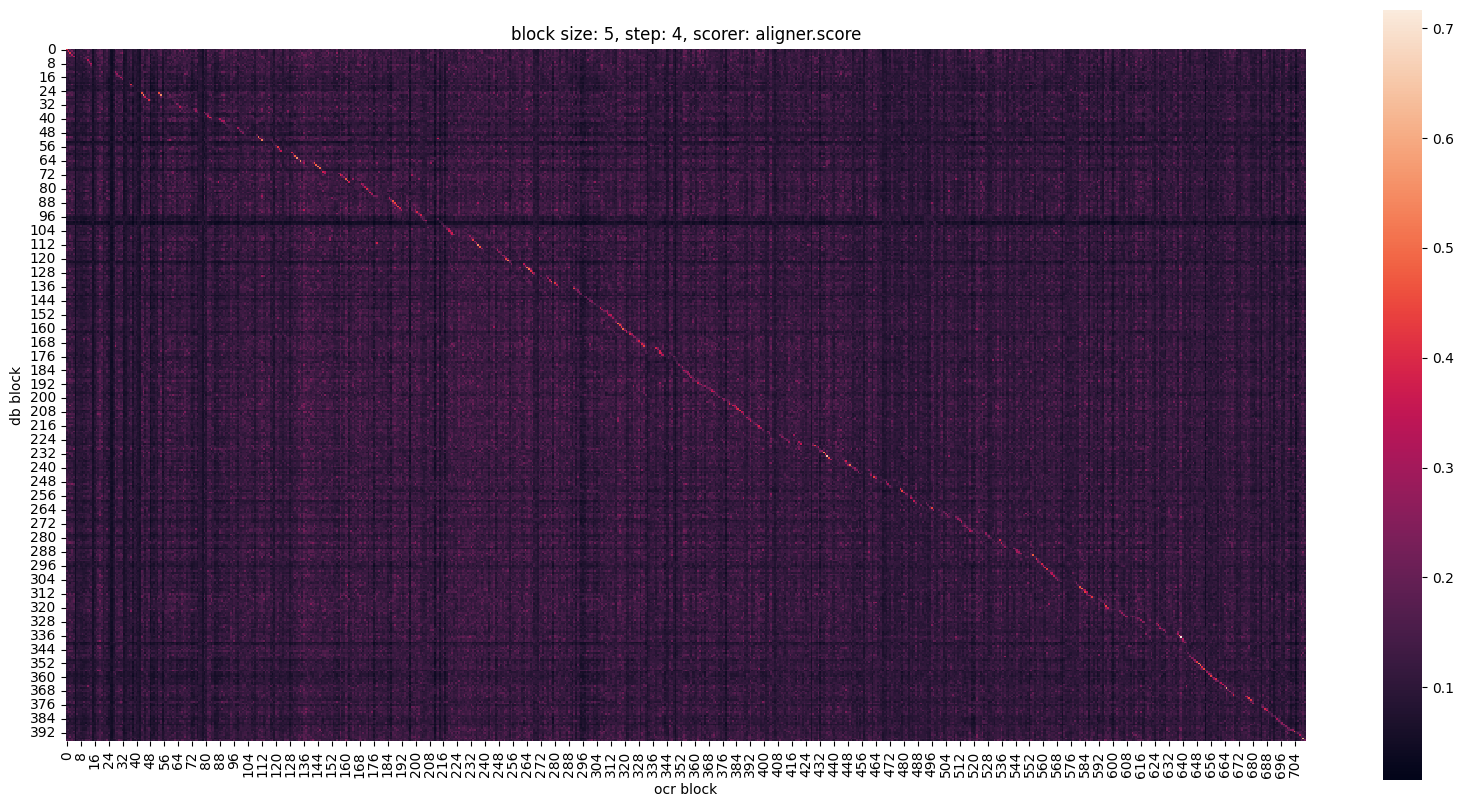

In [33]:
aligner = Align.PairwiseAligner(mode="local")
aligner.match_score = 1
aligner.mismatch_score = 0
aligner.gap_score = -2

db_rows = events_from_df

ocr_rows = []
for page in names:
    ocr_rows += page

block_size = 5
step = 4

db_slices, ocr_slices, db_ranges, ocr_ranges = create_db_slices(
    db_rows,
    ocr_rows,
    db_block_size=block_size,
    ocr_block_size=block_size,
    db_step=step,
    ocr_step=step,
    #db_range_end=1000,
    #ocr_range_end=1000,
)
m, coordinates = create_sim_m_and_alignments_m(
    db_slices=db_slices,
    ocr_slices=ocr_slices,
    aligner=aligner.align,
)
create_sim_m_heatmap(
    m=m,
    db_block_size=block_size,
    ocr_block_size=block_size,
    db_step=step,
    ocr_step=step,
    scorer="aligner.score",
)

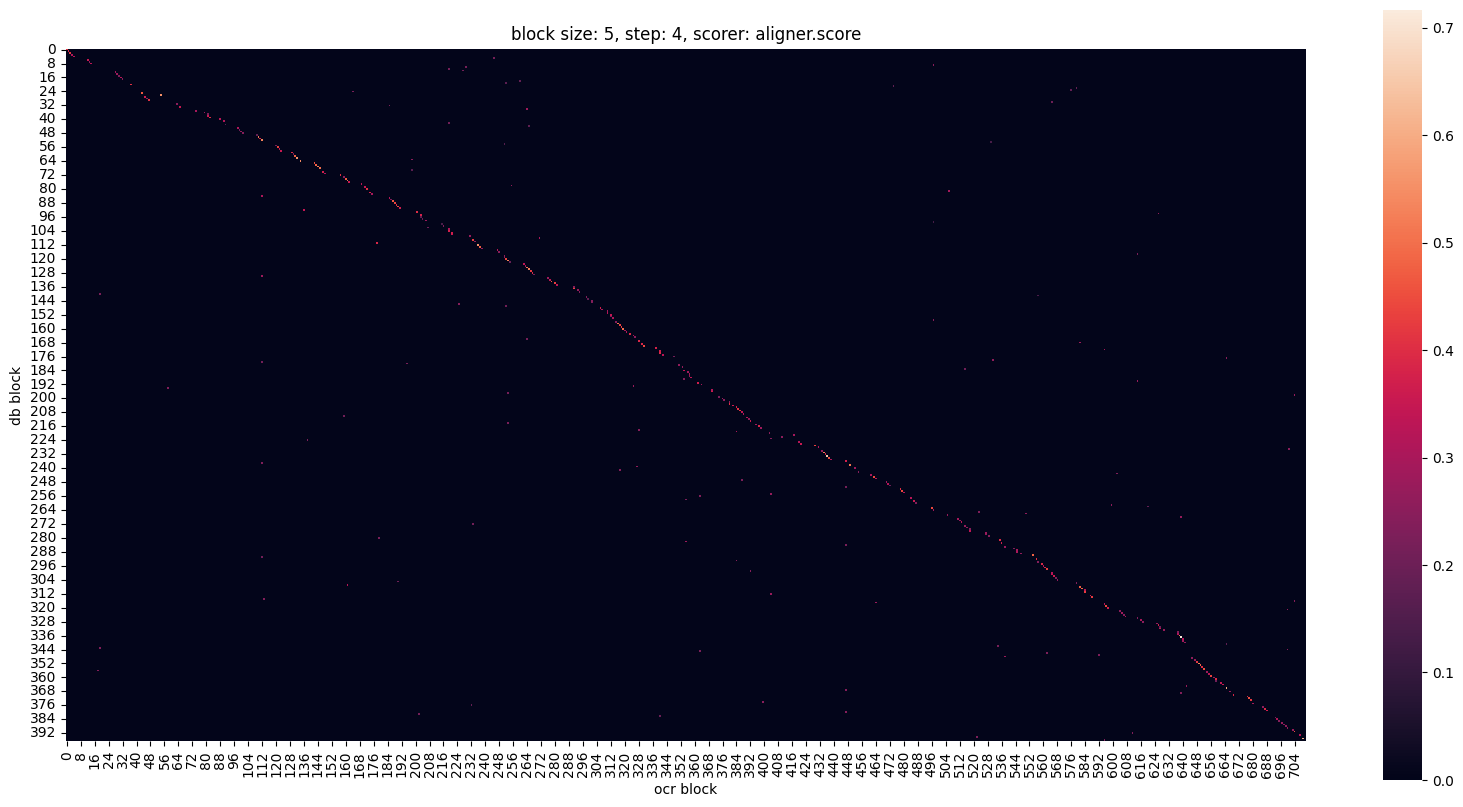

In [34]:
for x in m:
    x_max = x.max()
    x_argmax = x.argmax()

    x[:] = 0
    x[x_argmax] = x_max

create_sim_m_heatmap(
    m,
    scorer="aligner.score",
    db_block_size=block_size,
    ocr_block_size=block_size,
    db_step=step,
    ocr_step=step,
)

In [35]:
best_scores = []
for score_row, coordinates_row in zip(m, coordinates):
    best_score_idx = np.argmax(score_row)
    best_alignment = coordinates_row[best_score_idx]
    best_scores.append(
        {"score": score_row[best_score_idx], "alignment": best_alignment}
    )

In [36]:
page_lens = [len(page) for page in pages]

page_row_ranges = []
first_row_of_page = 0
for i in range(len(page_lens)):
    page_row_ranges.append(
        (first_row_of_page, first_row_of_page + page_lens[i])
    )
    first_row_of_page += page_lens[i]

ocr_ranges_to_book_page = {}
for ocr_range in ocr_ranges:
    ocr_ranges_to_book_page[ocr_range] = []
    for i in range(len(page_row_ranges)):
        if (
            ocr_range[1] >= page_row_ranges[i][0]
            and ocr_range[0] <= page_row_ranges[i][1]
        ):
            ocr_ranges_to_book_page[ocr_range].append(
                files_immigrated_sorted[i]
            )

In [37]:
def alignments_to_tuples(coordinates):
    target = [
        (coordinates[0][i * 2], coordinates[0][i * 2 + 1])
        for i in range(len(coordinates[0]) // 2)
    ]
    query = [
        (coordinates[1][i * 2], coordinates[1][i * 2 + 1])
        for i in range(len(coordinates[0]) // 2)
    ]

    return (target, query)

In [38]:
connections = []
for i, coordinates_row in zip(range(len(db_ranges)), coordinates):
    best_score_idx = np.argmax(m[i])
    best_alignment = coordinates_row[best_score_idx]
    connections.append(
        {
            "score": float(m[i, best_score_idx]),
            "best_alignment": alignments_to_tuples(
                [a.tolist() for a in best_alignment]
            ),
            "ranges": {"db": db_ranges[i], "ocr": ocr_ranges[best_score_idx]},
            "pages": ocr_ranges_to_book_page[ocr_ranges[best_score_idx]],
        }
    )

In [39]:
event_ids_to_pages = {}

for connection in connections:
    connection_event_ids = event_ids[slice(*connection["ranges"]["db"])]

    event_ids_to_pages.update(
        [(event_id, connection["pages"]) for event_id in connection_event_ids]
    )

    connection["event_ids"] = connection_event_ids


In [40]:
pages_with_events = {}

for event_id, pages in event_ids_to_pages.items():
    for page in pages:
        if pages_with_events.get(page) == None:
            pages_with_events[page] = []
        
        pages_with_events[page].append(event_id)

In [41]:
with open("db_match_to_page.json", "w") as json_file:
    json.dump(connections, json_file)

In [42]:
with open("db_event_to_page.json", "w") as json_file:
    json.dump(event_ids_to_pages, json_file)

In [43]:
with open("page_to_db_events.json", "w") as json_file:
    json.dump(pages_with_events, json_file)